# Regularisation (Ridge & Lasso)

### Objective

This notebook explores Ridge Regression, Lasso Regression, and Elastic Net Regression using the OASIS-1 brain MRI dataset.

Regularisation helps control model complexity by penalising large regression coefficients. Ridge and Lasso can also behave differently when predictors are correlated or when some predictors contribute little to the outcome.

### Research Question

How do Ridge, Lasso, and Elastic Net Regression perform with different types of healthcare predictors?

### Learning Objectives

- Understand why regularisation is useful
- Apply Ridge Regression, Lasso Regression, and Elastic Net Regression
- Compare the behaviour of the 3 methods
- Use continuous and categorical predictors
- Examine how regularisation affects model coefficients
- Explore mixed predictors and grouped relationships

## 01. Why Regularisation?

To prevent overfitting of data (when a regression line fits the training data too closely but does not generalise well to unseen data), regularisation is used to introduce a small amount of bias, so that a new line that is less sensitive to the training data may greatly reduce variance. 

The main regularisation methods explored in this notebook are:
1. Ridge Regression - shrinks coefficients towards 0
2. Lasso Regression - shrinks coefficients towards 0 and can set some coefficients exactly to 0
3. Elastic Net Regression - combines Ridge and Lasso Regression, allowing correlated variables to be grouped and shrunk correlated variables while potentially removing less useful variables

## 02. Prepare the Data

We will use the OASIS-1 MRI Brain Cross-Sectional Dataset. The outcome will be normalised whole brain volume (nWBV), while the predictors will include a mixture of continuous and categorical variables.

### 2.1 Load the Dataset

In [5]:
import pandas as pd
import numpy as np
print("Modules Imported")

df = pd.read_excel('oasis_cross-sectional-5708aa0a98d82080.xlsx')
df.head()

Modules Imported


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


### 2.2 Select Outcome and Predictors

We will use normalised whole brain volume (nWBV) as the continuous outcome. nWBV represents the percentage of cranial space being occupied by brain tissue. As people age, the brain physically shrinks (atrophy), causing the nWBV percentage to decrease. In a young healthy adult, nWBV is typically 80% to 85%. 

For the initial regression models, we will use
- Age - continuous
- MMSE (Mini-Mental State Examination) - continuous (0 to 30)
- Educ (Education) - ordinal categorical (1: less than high school grad; 2: high school grad; 3: some college; 4: college grad; 5: beyond college)
- SES (Socioeconomic Status) - ordinal categorical (1 to 5)
- M/F (Gender) - binary categorical

In [31]:
y = df['nWBV']
X = df[['Age', 'MMSE', 'Educ', 'SES', 'M/F']]

### 2.3 Encode categorical variables

Regression models require numerical inputs. Categorical variables need to be encoded. We will use one-hot encoding for SES and M/F. 

In [32]:
#Understanding data
print(df.columns.tolist())
print(df[['Age', 'MMSE', 'Educ', 'SES', 'M/F', 'nWBV']].head())
print("\nMissing values:")
print(df[['Age', 'MMSE', 'Educ', 'SES', 'M/F', 'nWBV']].isnull().sum())

#Clean data
df_model = df[['Age', 'MMSE', 'Educ', 'SES', 'M/F', 'nWBV']].dropna()
print("Original samples:", len(df))
print("Samples after removing missing values:", len(df_model))

#Check no missing data
print(df_model.isnull().sum())

#Encode categorical variables
X = df_model[['Age', 'MMSE', 'Educ', 'SES', 'M/F']]
y = df_model['nWBV']
X = pd.get_dummies(X, columns=['Educ', 'SES', 'M/F'],drop_first=True)
X.head()

['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay']
   Age  MMSE  Educ  SES M/F   nWBV
0   74  29.0   2.0  3.0   F  0.743
1   55  29.0   4.0  1.0   F  0.810
2   73  27.0   4.0  3.0   F  0.708
3   28   NaN   NaN  NaN   M  0.803
4   18   NaN   NaN  NaN   M  0.848

Missing values:
Age       0
MMSE    201
Educ    201
SES     220
M/F       0
nWBV      0
dtype: int64
Original samples: 436
Samples after removing missing values: 216
Age     0
MMSE    0
Educ    0
SES     0
M/F     0
nWBV    0
dtype: int64


,Age,MMSE,Educ_2.0,Educ_3.0,Educ_4.0,Educ_5.0,SES_2.0,SES_3.0,SES_4.0,SES_5.0,M/F_M
0,74,29.0,True,False,False,False,False,True,False,False,False
1,55,29.0,False,False,True,False,False,False,False,False,False
2,73,27.0,False,False,True,False,False,True,False,False,False
8,74,30.0,False,False,False,True,True,False,False,False,True
9,52,30.0,False,True,False,False,True,False,False,False,False


### 2.4 Split the Data

In this section, the data will be split into training set and testing set. The training set will be used to fit the regression models, while the testing set will be used to test the models afterwards.

In [33]:
from sklearn.model_selection import train_test_split

#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

#Check shapes - results (number of samples, number of features) - y only have 1 column hence empty second value.
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Training samples: 151
Testing samples: 65
X_train: (151, 11)
X_test: (65, 11)
y_train: (151,)
y_test: (65,)


### 2.5 Standardise and Scale Data

Since regularisation penalises coefficient sizes, predictors need to be on a comparable scale. Hence, we will standardise and fit the scaler only on the training dataset. Then, we will use that fitted scaler to transform both training and testing dataset. 

This distinction prevents data leakage, so that information from the testing dataset does not directly influence the training process.

In [34]:
from sklearn.preprocessing import StandardScaler

#Fit only training dataset, and transform both training and testing dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])  # Display first 5 rows of scaled training data

[[ 0.07205946  0.49514705 -0.53907169  1.72443736 -0.53907169 -0.52882986
  -0.66188763 -0.54929422  1.92840608 -0.08164966 -0.7677719 ]
 [-1.92812028  0.79302437 -0.53907169 -0.57989929  1.85504083 -0.52882986
   1.51083047 -0.54929422 -0.51856298 -0.08164966  1.30247018]
 [-0.16796211 -0.10060757 -0.53907169 -0.57989929  1.85504083 -0.52882986
  -0.66188763 -0.54929422 -0.51856298 -0.08164966  1.30247018]
 [ 1.43218168 -1.88787144  1.85504083 -0.57989929 -0.53907169 -0.52882986
  -0.66188763  1.82051798 -0.51856298 -0.08164966  1.30247018]
 [-0.2479693  -0.9942395   1.85504083 -0.57989929 -0.53907169 -0.52882986
   1.51083047 -0.54929422 -0.51856298 -0.08164966  1.30247018]]


## 03. Ridge Regression

Ridge Regression is a regularisation method that adds a L2 regularisation penalty to shrink coefficient estimates and prevent overfitting. It accepts a small increase in bias to significantly reduce variance, improving predictions on unseen data. 

Ridge Regression shrinks coefficients towards 0, but never makes them exactly 0.

The strength of regression is controlled by lambda (λ). In scikit-learn, this parameter is called alpha.
- Small λ --> weaker regularisation
- Large λ --> stronger regularisation

### 3.1 Continuous Predictors

#### 3.1.1 Ridge Model on age and MMSE with λ=1

In [35]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

#Use only continuous variables for Ridge Regression
X_train_cont = X_train[['Age', 'MMSE']]
X_test_cont = X_test[['Age', 'MMSE']]
scaler_cont = StandardScaler()
X_train_cont_scaled = scaler_cont.fit_transform(X_train_cont)
X_test_cont_scaled = scaler_cont.transform(X_test_cont)

#Fit Ridge Regression model with λ=1
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_cont_scaled, y_train)
y_pred = ridge.predict(X_test_cont_scaled)

#Check performance
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

#Examine coefficients
coefficients = pd.Series(ridge.coef_, index=['Age', 'MMSE'])
print(coefficients)

R2: 0.6343344390450283
MSE: 0.0009862779976992084
Age    -0.029196
MMSE    0.012469
dtype: float64


In this Ridge Regression model, we have an R^2 value of 0.634. The Ridge model explains about 63.4% of the variation in nWBV using age and MMSE. 

The coefficient of age is -0.0292, while the coefficient for MMSE is 0.0125, on the standardised predictor scale. In this model, higher age is associated with lower predicted nWBV, while higher MMSE is associated with higher predicted nWBV. 

#### 3.1.2 Ridge Model on age and MMSE with different λ values

We will use different λ values to see the effect of Ridge Regularisation. 

In [38]:
alphas = [0, 1, 10, 100, 1000]
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_cont_scaled, y_train)
    y_pred = ridge.predict(X_test_cont_scaled)
    print(f"λ: {alpha:<6}")
    print(f"R2: {r2_score(y_test, y_pred):.4f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"Age coefficient: {ridge.coef_[0]:.4f}")
    print(f"MMSE coefficient: {ridge.coef_[1]:.4f}")

λ: 0     
R2: 0.6356
MSE: 0.0010
Age coefficient: -0.0294
MMSE coefficient: 0.0125
λ: 1     
R2: 0.6343
MSE: 0.0010
Age coefficient: -0.0292
MMSE coefficient: 0.0125
λ: 10    
R2: 0.6223
MSE: 0.0010
Age coefficient: -0.0276
MMSE coefficient: 0.0122
λ: 100   
R2: 0.5014
MSE: 0.0013
Age coefficient: -0.0182
MMSE coefficient: 0.0096
λ: 1000  
R2: 0.1336
MSE: 0.0023
Age coefficient: -0.0043
MMSE coefficient: 0.0027


As λ increases, the Ridge penalty becomes stronger and the coefficient for age and MMSE becomes smaller. This demonstrates how Ridge Regression shrinks coefficients towards 0 to reduce model complexity. 

Stronger regularisation (λ = 100 and beyond) substantially reduces model's R^2, illustrating the bias-variance trade-off whereby stronger regularisation reduces coefficient size and overfitting, but too much regularisation can introduce too much bias and cause underfitting.

### 3.2 Categorical Predictors

#### 3.2.1 Ridge Model on Education, SES, and Gender with λ=1

In [ ]:
#Identify categorical columns
categorical_columns = [col for col in X_train.columns if col.startswith('Educ_') or col.startswith('SES_') or col == 'M/F_M']
print(categorical_columns)

#Create categorical-only training and testing sets
X_train_cat = X_train[categorical_columns]
X_test_cat = X_test[categorical_columns]

#Standardize categorical variables
scaler_cat = StandardScaler()
X_train_cat_scaled = scaler_cat.fit_transform(X_train_cat)
X_test_cat_scaled = scaler_cat.transform(X_test_cat)

#Fit Ridge model (categorical variables only) with λ=1
ridge_cat = Ridge(alpha=1.0)
ridge_cat.fit(X_train_cat_scaled, y_train)
y_pred_cat = ridge_cat.predict(X_test_cat_scaled)

#Check performance
print("R2 (categorical only):", r2_score(y_test, y_pred_cat))
print("MSE (categorical only):", mean_squared_error(y_test, y_pred_cat))

#Examine coefficients
coefficients_cat = pd.Series(ridge_cat.coef_, index=categorical_columns)
print(coefficients_cat)

['Educ_2.0', 'Educ_3.0', 'Educ_4.0', 'Educ_5.0', 'SES_2.0', 'SES_3.0', 'SES_4.0', 'SES_5.0', 'M/F_M']
R2 (categorical only): 0.054186515582779204
MSE (categorical only): 0.0025510606663961934
Educ_2.0    0.008825
Educ_3.0    0.011358
Educ_4.0    0.013509
Educ_5.0    0.012784
SES_2.0     0.005568
SES_3.0     0.003815
SES_4.0     0.000442
SES_5.0    -0.001814
M/F_M      -0.007086
dtype: float64


With an R^2 value of 0.0542 and MSE of 0.00255, it demonstrates that categorical-only model explains only about 5.42% of the test-set variation in nWBV, and are much weaker predictors of nWBV than Age + MMSE. 

#### 3.2.2 Ridge Model on Education, SES, and Gender with different λ values

As with the Ridge Regression Model on continuous variables, we will use different λ values to see the effect of Ridge Regularisation on categorical variables.

In [43]:
alphas = [0, 1, 10, 100, 1000]
for alpha in alphas:
    ridge_cat = Ridge(alpha=alpha)
    ridge_cat.fit(X_train_cat_scaled, y_train)
    y_pred_cat = ridge_cat.predict(X_test_cat_scaled)
    print(f"λ: {alpha}")
    print(f"R2: {r2_score(y_test, y_pred_cat):.4f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred_cat):.4f}")
    for feature, coefficient in zip(categorical_columns, ridge_cat.coef_):
        print(f"{feature} coefficient: {coefficient:.4f}")

λ: 0
R2: 0.0578
MSE: 0.0025
Educ_2.0 coefficient: 0.0097
Educ_3.0 coefficient: 0.0124
Educ_4.0 coefficient: 0.0148
Educ_5.0 coefficient: 0.0141
SES_2.0 coefficient: 0.0058
SES_3.0 coefficient: 0.0042
SES_4.0 coefficient: 0.0011
SES_5.0 coefficient: -0.0016
M/F_M coefficient: -0.0071
λ: 1
R2: 0.0542
MSE: 0.0026
Educ_2.0 coefficient: 0.0088
Educ_3.0 coefficient: 0.0114
Educ_4.0 coefficient: 0.0135
Educ_5.0 coefficient: 0.0128
SES_2.0 coefficient: 0.0056
SES_3.0 coefficient: 0.0038
SES_4.0 coefficient: 0.0004
SES_5.0 coefficient: -0.0018
M/F_M coefficient: -0.0071
λ: 10
R2: 0.0332
MSE: 0.0026
Educ_2.0 coefficient: 0.0047
Educ_3.0 coefficient: 0.0067
Educ_4.0 coefficient: 0.0078
Educ_5.0 coefficient: 0.0072
SES_2.0 coefficient: 0.0045
SES_3.0 coefficient: 0.0022
SES_4.0 coefficient: -0.0022
SES_5.0 coefficient: -0.0028
M/F_M coefficient: -0.0068
λ: 100
R2: 0.0079
MSE: 0.0027
Educ_2.0 coefficient: 0.0004
Educ_3.0 coefficient: 0.0020
Educ_4.0 coefficient: 0.0020
Educ_5.0 coefficient: 0.0017


As λ increases, the Ridge penalty becomes stronger and the coefficients of the categorical predictors shrink towards 0. However, none of the coefficients become exactly 0. This is an important characteristic of Ridge Regression. Very large values of λ can shrink the coefficients too strongly, causing the model to underfit and perform worse than the baseline mean prediction on the test set.

## 04. Lasso Regression

Lasso Regression is another regularisation method that penalises large coefficients. Like Ridge, Lasso shrinks coefficients towards 0. However, Lasso can shrink some coefficients exactly to 0, effectively removing those predictors from the model. 

The strength of regularisation is controlled by lambda (λ), just as with Ridge Regression:
- Small λ --> weaker regularisation
- Large λ --> stronger regularisation

### 4.1 Continuous Predictors

Using the same continuous predictors of Age and MMSE, and outcome of nWBV, we will now perform Lasso Regression.

#### 4.1.1 Lasso Model on age and MMSE with λ=1

In [45]:
from sklearn.linear_model import Lasso

#Fit Lasso Regression model with λ=0.001
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_cont_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_cont_scaled)

#Check performance
print("R^2 (Lasso):", r2_score(y_test, y_pred_lasso))
print("MSE (Lasso):", mean_squared_error(y_test, y_pred_lasso))

#Examine coefficients
coefficients_lasso = pd.Series(lasso.coef_, index=['Age', 'MMSE'])
print(coefficients_lasso)

R^2 (Lasso): 0.6274092905258795
MSE (Lasso): 0.0010049566000740074
Age    -0.028620
MMSE    0.011732
dtype: float64


#### 4.1.2 Lasso Model on age and MMSE with different λ values

We will use different λ values to see the effect of Lasso Regularisation.

In [46]:
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1]
for alpha in alphas:
    if alpha == 0:
        print("λ: 0 (Linear Regression instead of Lasso)")
        continue
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_cont_scaled, y_train)
    y_pred_lasso = lasso.predict(X_test_cont_scaled)
    print(f"λ: {alpha}")
    print(f"R2: {r2_score(y_test, y_pred_lasso):.4f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}")
    print(f"Age coefficient: {lasso.coef_[0]:.4f}")
    print(f"MMSE coefficient: {lasso.coef_[1]:.4f}")

λ: 0 (Linear Regression instead of Lasso)
λ: 0.0001
R2: 0.6349
MSE: 0.0010
Age coefficient: -0.0293
MMSE coefficient: 0.0124
λ: 0.001
R2: 0.6274
MSE: 0.0010
Age coefficient: -0.0286
MMSE coefficient: 0.0117
λ: 0.01
R2: 0.5023
MSE: 0.0013
Age coefficient: -0.0218
MMSE coefficient: 0.0049
λ: 0.1
R2: -0.0325
MSE: 0.0028
Age coefficient: 0.0000
MMSE coefficient: 0.0000
λ: 1
R2: -0.0325
MSE: 0.0028
Age coefficient: 0.0000
MMSE coefficient: 0.0000


As λ increases, Lasso increasingly penalises both coefficients. Unlike Ridge Regression, Lasso can shrink coefficients exactly to 0, effectively removing those predictors from the model. In this model, both age and MMSE are reduced to 0 at λ = 0.1. At this point, the model becomes too simple and underfits the data, resulting in poorer test performance. The negative R^2 value starting from λ = 0.1 means the model performs worse than simply predicting mean nWBV for every test observation.

### 4.2 Categorical Predictors

#### 4.2.1 Lasso Model on Education, SES, and Gender with λ=0.001

In [47]:
from sklearn.linear_model import Lasso

#Fit Lasso model (categorical variables only) with λ=0.001
lasso_cat = Lasso(alpha=0.001)
lasso_cat.fit(X_train_cat_scaled, y_train)
y_pred_lasso_cat = lasso_cat.predict(X_test_cat_scaled)

#Check performance
print("R^2 (Lasso, categorical only):", r2_score(y_test, y_pred_lasso_cat))
print("MSE (Lasso, categorical only):", mean_squared_error(y_test, y_pred_lasso_cat))

#Examine coefficients
coefficients_lasso_cat = pd.Series(lasso_cat.coef_, index=categorical_columns)
print(coefficients_lasso_cat)

R^2 (Lasso, categorical only): 0.00010877396931441297
MSE (Lasso, categorical only): 0.002696919867846097
Educ_2.0    0.000000
Educ_3.0    0.001368
Educ_4.0    0.001443
Educ_5.0    0.000898
SES_2.0     0.003010
SES_3.0     0.000000
SES_4.0    -0.004610
SES_5.0    -0.003213
M/F_M      -0.006426
dtype: float64


At λ=0.001, the coefficients of educ_2.0 and SES_3.0 predictors are at 0, effectively removing these two predictors from the model. 

#### 4.2.2 Lasso Model on Education, SES, and Gender with different λ values

As with the Lasso Regression Model on continuous variables, we will use different λ values to see the effect of Lasso Regularisation on categorical variables.

In [48]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1]
for alpha in alphas:
    lasso_cat = Lasso(alpha=alpha)
    lasso_cat.fit(X_train_cat_scaled, y_train)
    y_pred_lasso_cat = lasso_cat.predict(X_test_cat_scaled)
    print(f"λ: {alpha}")
    print(f"R2: {r2_score(y_test, y_pred_lasso_cat):.4f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred_lasso_cat):.4f}")
    for feature, coefficient in zip(categorical_columns, lasso_cat.coef_):
        print(f"{feature} coefficient: {coefficient:.6f}")

λ: 0.0001
R2: 0.0539
MSE: 0.0026
Educ_2.0 coefficient: 0.008562
Educ_3.0 coefficient: 0.011059
Educ_4.0 coefficient: 0.013005
Educ_5.0 coefficient: 0.012293
SES_2.0 coefficient: 0.005282
SES_3.0 coefficient: 0.003449
SES_4.0 coefficient: 0.000000
SES_5.0 coefficient: -0.001842
M/F_M coefficient: -0.007032
λ: 0.001
R2: 0.0001
MSE: 0.0027
Educ_2.0 coefficient: 0.000000
Educ_3.0 coefficient: 0.001368
Educ_4.0 coefficient: 0.001443
Educ_5.0 coefficient: 0.000898
SES_2.0 coefficient: 0.003010
SES_3.0 coefficient: 0.000000
SES_4.0 coefficient: -0.004610
SES_5.0 coefficient: -0.003213
M/F_M coefficient: -0.006426
λ: 0.01
R2: -0.0325
MSE: 0.0028
Educ_2.0 coefficient: 0.000000
Educ_3.0 coefficient: 0.000000
Educ_4.0 coefficient: 0.000000
Educ_5.0 coefficient: 0.000000
SES_2.0 coefficient: 0.000000
SES_3.0 coefficient: 0.000000
SES_4.0 coefficient: 0.000000
SES_5.0 coefficient: 0.000000
M/F_M coefficient: 0.000000
λ: 0.1
R2: -0.0325
MSE: 0.0028
Educ_2.0 coefficient: 0.000000
Educ_3.0 coefficient

As λ increases, Lasso increasingly shrinks the coefficients of the categorical predictors towards 0. 
At λ=0.001, some coefficients are reduced to exactly 0, effectively removing these predictors from the model.
At λ=0.01, Lasso has effectively removed every predictor. The negative R^2 indicates that this mode performs worse than simply predicting the nWBV. The model has become too simple and underfits the data, resulting in poor test performance.

The predictors removed by Lasso should not be interpreted as definitive evidence that a variable is medically unimportant. The results depend on the dataset, model, and chosen λ value.

## 05. Elastic Net Regression

Elastic Net Regression combines both Ridge and Lasso Regression. It has 2 parameters. Lambda (λ) controls the overall strength of regularisation, and L1_ratio controls the balance between Lasso and Ridge.

L1_ratio ranges from 0 to 1, where:
- L1_ratio = 0 --> Ridge-like
- L1_ratio = 1 --> Lasso-like

We will first use L1_ratio = 0.5, giving equal weight to the two penalties.

### 5.1 Continuous Predictors

Using the same continuous of Age and MMSE, we will now perform Elastic Net Regression at l1_ratio = 0.5.

In [50]:
from sklearn.linear_model import ElasticNet

#Fit Elastic Net model with λ=0.001 and l1_ratio=0.5
elastic = ElasticNet(alpha=0.001, l1_ratio=0.5)
elastic.fit(X_train_cont_scaled, y_train)
y_pred_elastic = elastic.predict(X_test_cont_scaled)

#Check performance
print("R^2 (Elastic Net):", r2_score(y_test, y_pred_elastic))
print("MSE (Elastic Net):", mean_squared_error(y_test, y_pred_elastic))

#Examine coefficients
coefficients_elastic = pd.Series(elastic.coef_, index=['Age', 'MMSE'])
print(coefficients_elastic)

#Varying λ
alphas = [0.0001, 0.001, 0.01, 0.1, 1]
for alpha in alphas:
    elastic = ElasticNet(alpha=alpha, l1_ratio=0.5)
    elastic.fit(X_train_cont_scaled, y_train)
    y_pred_elastic = elastic.predict(X_test_cont_scaled)
    print(f"λ: {alpha}")
    print(f"R2: {r2_score(y_test, y_pred_elastic):.4f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred_elastic):.4f}")
    print(f"Age coefficient: {elastic.coef_[0]:.4f}")
    print(f"MMSE coefficient: {elastic.coef_[1]:.4f}")

R^2 (Elastic Net): 0.6315625728565797
MSE (Elastic Net): 0.00099375431192222
Age    -0.028987
MMSE    0.012111
dtype: float64
λ: 0.0001
R2: 0.6352
MSE: 0.0010
Age coefficient: -0.0293
MMSE coefficient: 0.0125
λ: 0.001
R2: 0.6316
MSE: 0.0010
Age coefficient: -0.0290
MMSE coefficient: 0.0121
λ: 0.01
R2: 0.5819
MSE: 0.0011
Age coefficient: -0.0255
MMSE coefficient: 0.0087
λ: 0.1
R2: -0.0325
MSE: 0.0028
Age coefficient: 0.0000
MMSE coefficient: 0.0000
λ: 1
R2: -0.0325
MSE: 0.0028
Age coefficient: 0.0000
MMSE coefficient: 0.0000


With l1_ratio - 0.5, Elastic Net combines Ridge and Lasso Regression, therefore combining two behaviours:
Ridge regularisation shrinks coefficients towards 0.
Lasso regularisation can shrink coefficients exactly to 0.
Elastic Net combines both types of regularisation.
The l1_ratio controls the balance between the Ridge and Lasso penalties.

At λ = 0.1, both coefficients are reduced to exactly 0, causing the model to underfit.

### 5.2 Categorical Predictors

We will now apply Elastic Net Regression to the categorical predictors, using the same variables as Ridge and Lasso, at λ = 0.001 and l1_ratio = 0.5.

In [53]:
#Fit Elastic Net model with λ=0.001 and l1_ratio=0.5 (categorical features only)
elastic_cat = ElasticNet(alpha=0.001, l1_ratio=0.5)
elastic_cat.fit(X_train_cat_scaled, y_train)
y_pred_elastic_cat = elastic_cat.predict(X_test_cat_scaled)

#Check performance
print("R^2 (Elastic Net, categorical only):", r2_score(y_test, y_pred_elastic_cat))
print("MSE (Elastic Net, categorical only):", mean_squared_error(y_test, y_pred_elastic_cat))

#Examine coefficients
coefficients_elastic_cat = pd.Series(elastic_cat.coef_, index=categorical_columns)
print(coefficients_elastic_cat)

#Varying λ for Elastic Net (categorical features only)
alphas = [0.0001, 0.001, 0.01, 0.1, 1]
for alpha in alphas:
    elastic_cat = ElasticNet(alpha=alpha, l1_ratio=0.5)
    elastic_cat.fit(X_train_cat_scaled, y_train)
    y_pred_elastic_cat = elastic_cat.predict(X_test_cat_scaled)
    print(f"λ: {alpha}")
    print(f"R2: {r2_score(y_test, y_pred_elastic_cat):.4f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred_elastic_cat):.4f}")
    for feature, coefficient in zip(categorical_columns, elastic_cat.coef_):
        print(f"{feature} coefficient: {coefficient:.6f}")

R^2 (Elastic Net, categorical only): 0.03326400432705645
MSE (Elastic Net, categorical only): 0.0026074931410712543
Educ_2.0    0.004268
Educ_3.0    0.006349
Educ_4.0    0.007460
Educ_5.0    0.006820
SES_2.0     0.004260
SES_3.0     0.001835
SES_4.0    -0.002078
SES_5.0    -0.002533
M/F_M      -0.006783
dtype: float64
λ: 0.0001
R2: 0.0558
MSE: 0.0025
Educ_2.0 coefficient: 0.009123
Educ_3.0 coefficient: 0.011698
Educ_4.0 coefficient: 0.013823
Educ_5.0 coefficient: 0.013097
SES_2.0 coefficient: 0.005496
SES_3.0 coefficient: 0.003761
SES_4.0 coefficient: 0.000441
SES_5.0 coefficient: -0.001724
M/F_M coefficient: -0.007068
λ: 0.001
R2: 0.0333
MSE: 0.0026
Educ_2.0 coefficient: 0.004268
Educ_3.0 coefficient: 0.006349
Educ_4.0 coefficient: 0.007460
Educ_5.0 coefficient: 0.006820
SES_2.0 coefficient: 0.004260
SES_3.0 coefficient: 0.001835
SES_4.0 coefficient: -0.002078
SES_5.0 coefficient: -0.002533
M/F_M coefficient: -0.006783
λ: 0.01
R2: -0.0194
MSE: 0.0027
Educ_2.0 coefficient: -0.000000
Ed

At λ=0.01, several categorical predictors are shrunk to 0, effectively removing them from the model.

At λ=0.1, all coefficients are shrunk to 0, causing the model to underfit.

Compared with Ridge, Elastic Net can remove predictors through its Lasso component. Compared with Lasso, the additional Ridge component provides Elastic Net with extra coefficient shrinkage and can be useful when predictors are correlated. 

## 06. Mixed Predictors (Continuous + Categorical)

### 6.1 Ridge (Mixed)

In [54]:
#Fit Ridge model with λ=1 (mixed features)
ridge_mixed = Ridge(alpha=1)
ridge_mixed.fit(X_train_scaled, y_train)
y_pred_ridge_mixed = ridge_mixed.predict(X_test_scaled)

#Check performance
print("R^2 (Ridge, mixed features):", r2_score(y_test, y_pred_ridge_mixed))
print("MSE (Ridge, mixed features):", mean_squared_error(y_test, y_pred_ridge_mixed))

#Examine coefficients
coefficients_ridge_mixed = pd.Series(ridge_mixed.coef_, index=X_train.columns)
print(coefficients_ridge_mixed)

R^2 (Ridge, mixed features): 0.6364104818878527
MSE (Ridge, mixed features): 0.0009806784674267618
Age        -0.029819
MMSE        0.011783
Educ_2.0    0.006298
Educ_3.0    0.004804
Educ_4.0    0.002559
Educ_5.0    0.004756
SES_2.0     0.002292
SES_3.0     0.003209
SES_4.0     0.000482
SES_5.0     0.001518
M/F_M      -0.006970
dtype: float64


The mixed Ridge model combines continuous and categorical predictors in the same regression model. Using age and MMSE alone gave an R^2 of approximately 0.634. After adding the categorical predictors, the R^2 increased slightly to 0.636. This suggests that the additional categorical predictors provide only a small improvement in predictive performance for this dataset. Age and MMSE remain the larger contributors in this model, while the categorical predictors have smaller coefficients.

This section demonstrates that Ridge Regression can handle a mixture of continuous and categorical variables within the same model.

### 6.2 Lasso (Mixed)

In [55]:
#Fit Lasso model with λ=0.001 (mixed features)
lasso_mixed = Lasso(alpha=0.001)
lasso_mixed.fit(X_train_scaled, y_train)
y_pred_lasso_mixed = lasso_mixed.predict(X_test_scaled)

#Check performance
print("R^2 (Lasso, mixed features):", r2_score(y_test, y_pred_lasso_mixed))
print("MSE (Lasso, mixed features):", mean_squared_error(y_test, y_pred_lasso_mixed))

#Examine coefficients
coefficients_lasso_mixed = pd.Series(lasso_mixed.coef_, index=X_train.columns)
print(coefficients_lasso_mixed)

R^2 (Lasso, mixed features): 0.6319397332122965
MSE (Lasso, mixed features): 0.0009927370300117323
Age        -0.029211
MMSE        0.011245
Educ_2.0    0.001896
Educ_3.0    0.000443
Educ_4.0   -0.000999
Educ_5.0    0.000000
SES_2.0     0.000954
SES_3.0     0.001399
SES_4.0    -0.000713
SES_5.0     0.000000
M/F_M      -0.006528
dtype: float64


The mixed Lasso model achieved R^2 of approximately 0.632, which is slightly lower than the mixed Ridge model. Mixed Lasso also shrank two categorical predictors, Educ_5.0 and SES_5.0, to exactly 0. These predictors are therefore excluded from the model at this level of regularisation.

This demonstrates how Lasso can perform feature selection when continuous and categorical predictors are included together. 

### 6.3 Elastic Net (Mixed)

In [56]:
#Fit Elastic Net model with λ=0.001 and l1_ratio=0.5 (mixed features)
elastic_mixed = ElasticNet(alpha=0.001, l1_ratio=0.5)
elastic_mixed.fit(X_train_scaled, y_train)
y_pred_elastic_mixed = elastic_mixed.predict(X_test_scaled)

#Check performance
print("R^2 (Elastic Net, mixed features):", r2_score(y_test, y_pred_elastic_mixed))
print("MSE (Elastic Net, mixed features):", mean_squared_error(y_test, y_pred_elastic_mixed))

#Examine coefficients
coefficients_elastic_mixed = pd.Series(elastic_mixed.coef_, index=X_train.columns)
print(coefficients_elastic_mixed)

R^2 (Elastic Net, mixed features): 0.6364297552723492
MSE (Elastic Net, mixed features): 0.0009806264829986396
Age        -0.029623
MMSE        0.011499
Educ_2.0    0.003601
Educ_3.0    0.002002
Educ_4.0   -0.000002
Educ_5.0    0.001489
SES_2.0     0.001459
SES_3.0     0.002018
SES_4.0    -0.000567
SES_5.0     0.000313
M/F_M      -0.006795
dtype: float64


The mixed Elastic Net model achieved at R^2 of approximately 0.636 on the test set, almost identical to the Ridge model and slightly higher than the Lasso model.

At λ=0.001 and l1_ratio = 0.5, none of the coefficients are exactly 0. Hence, no predictors are removed from the model at this level of regularisation.

This demonstrates how Elastic Net can behave differently based on the balance (l1_ratio) between its Ridge and Lasso components. The effect of l1_ratio and λ depends on the dataset and should be evaluated rather than assuming that one regularisation method will perform best. 

In [57]:
comparison = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'R²': [0.6364, 0.6319, 0.6364],
    'MSE': [0.000981, 0.000993, 0.000981]
})

print(comparison)

         Model      R²       MSE
0        Ridge  0.6364  0.000981
1        Lasso  0.6319  0.000993
2  Elastic Net  0.6364  0.000981


### Comparing the Regularisation Methods

Using the same mixed set of continuous and categorical predictors:

* Ridge and Elastic Net achieved very similar test-set performance.
* Lasso had slightly lower R² and slightly higher MSE.
* Lasso removed some predictors by shrinking their coefficients exactly to 0.
* Ridge retained all predictors.
* Elastic Net retained all predictors at the selected regularisation settings.

The best method is not determined solely by test-set R². Regularisation strength, feature selection, model stability, and the purpose of the model should also be considered.

## 07. Grouped Data / Interactions

The relationship between 2 continuous variables may differ between groups. For example, we can examine the relationship between age and nWBV separately for males and females. If the relationship differs between groups, an interaction term can be used to model this: Age x Gender.

An interaction allows the effect of one predictor to depend on another predictor. In larger models, interactions can increase model complexity and introduce additional correlated predictors. Regularisation helps control this by shrinking their coefficients. 

In this example, we will use age as the predictor, nWBV as the outcome, and gender (M/F) as the grouping variable.

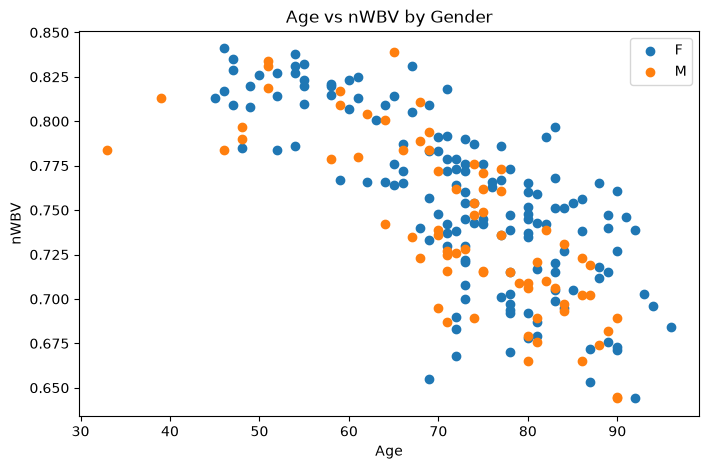

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for group in df_model['M/F'].unique():
    group_data = df_model[df_model['M/F'] == group]
    plt.scatter(group_data['Age'], group_data['nWBV'], label=group)

plt.xlabel('Age')
plt.ylabel('nWBV')
plt.title('Age vs nWBV by Gender')
plt.legend()
plt.show()    

### Interpretation

The plot shows a general negative relationship between age and nWBV: older participants tend to have lower nWBV. 

The 2 groups show substantial overlap and appear to follow a similar overall trend. There is no obvious visual evidence that the relationship between age and nWBV differs substantially between the groups. This suggests that an Age x Gender interaction may not add much predictive value in this dataset.

## 08. Key takeaways

Regularisation helps control model complexity by penalising large coefficients.

### Ridge Regression

- Shrinks coefficients towards 0
- Generally keeps all predictors in model
- Useful when many predictors contribute to outcome, particularly when predictors are correlated

### Lasso Regression

- Shrinks coefficients to 0
- Allows for feature selection

### Elastic Net Regression

- Combines Ridge and Lasso
- λ controls overall strength of regularisation
- l1_ratio controls balance between Ridge and Lasso features
- Provides both coefficient shrinkage and feature selection

### Overall

The choice of regularisation method and strength depends on the dataset and modelling objective. Stronger regularisation is not always better: if the penalty is too large, important predictors may be overly shrunk and the model may underfit.